# Explore here

In [8]:
# Your code here
import pandas as pd

# Cargar el dataset 
url = "https://raw.githubusercontent.com/4GeeksAcademy/decision-tree-project-tutorial/main/diabetes.csv"
df = pd.read_csv(url)

# Mostrar las primeras filas
print("--- Primeras 5 filas ---")
print(df.head())
print("\n--- Información de las columnas ---")
print(df.info())

--- Primeras 5 filas ---
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

--- Información de las columnas ---
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non

In [7]:
# cuántos valores en 0 hay?
cols_con_ceros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("Valores en 0 por columna:")
print((df[cols_con_ceros] == 0).sum())

# separar los datos en X (características) y Y (objetivo)
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

from sklearn.model_selection import train_test_split

# se dividimos: 80% para entrenar y 20% para probar después
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\n¡Datos divididos! X_train tiene", X_train.shape[0], "filas.")

Valores en 0 por columna:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

¡Datos divididos! X_train tiene 614 filas.


In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# se crea el modelo usando el criterio 'gini'
model_gini = DecisionTreeClassifier(criterion='gini', random_state=42)

# se entrenacon los datos de entrenamiento
model_gini.fit(X_train, y_train)

# se prueba qué tan bueno es con los datos de prueba
y_pred = model_gini.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"La precisión del modelo (Gini) es: {accuracy * 100:.2f}%")

La precisión del modelo (Gini) es: 74.68%


In [10]:
# se entrenamos un segundo modelo usando 'entropy'
model_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
model_entropy.fit(X_train, y_train)

# comparar resultados
y_pred_entropy = model_entropy.predict(X_test)
acc_entropy = accuracy_score(y_test, y_pred_entropy)

print(f"Precisión con Gini: {accuracy * 100:.2f}%")
print(f"Precisión con Entropy: {acc_entropy * 100:.2f}%")

Precisión con Gini: 74.68%
Precisión con Entropy: 72.08%


In [20]:
from sklearn.model_selection import GridSearchCV

# Definir los parámetros que se quieren probar
parametros = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 3, 5, 7, 10],      # Profundidad del árbol
    'min_samples_split': [2, 5, 10],       # Mínimo de muestras para dividir un nodo
    'min_samples_leaf': [1, 2, 4]          # Mínimo de muestras en una "hoja"
}

# se inicia la búsqueda (esto probará todas las combinaciones)
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), parametros, cv=5)
grid_search.fit(X_train, y_train)

# este es el mejor modelo encontrado
best_model = grid_search.best_estimator_

print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Precisión del mejor modelo: {grid_search.best_score_ * 100:.2f}%")

Mejores parámetros: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2}
Precisión del mejor modelo: 75.90%


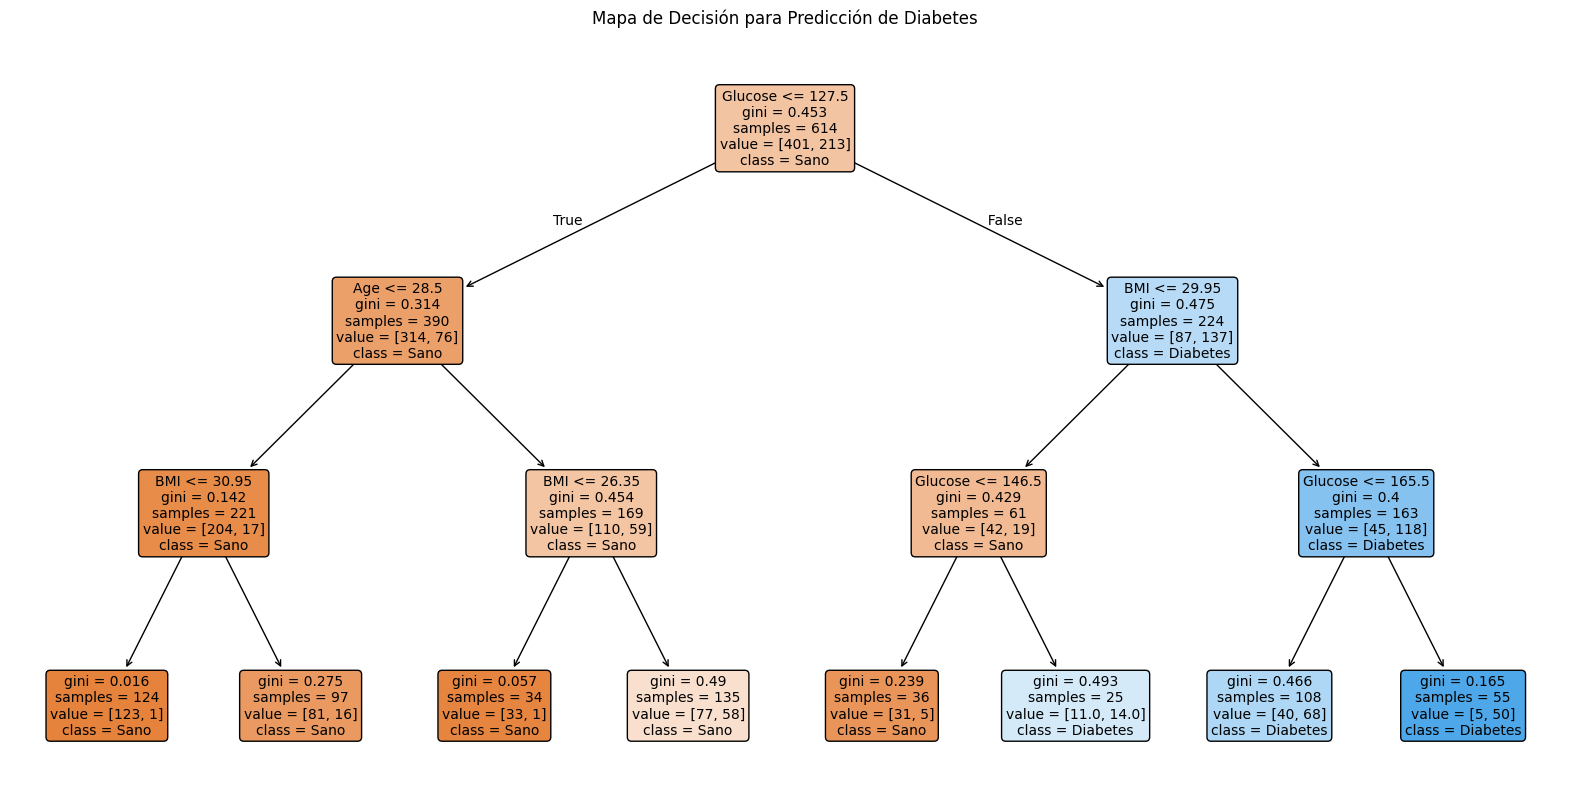

In [19]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# se configura el tamaño de la imagen
plt.figure(figsize=(20,10))

# se dibuja el árbol usando el mejor modelo encontrado
plot_tree(best_model, 
          feature_names=X.columns, 
          class_names=["Sano", "Diabetes"], 
          filled=True, 
          rounded=True, 
          fontsize=10)

plt.title("Mapa de Decisión para Predicción de Diabetes")
plt.show()

/tmp/ipykernel_3245/661710735.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=importancia, palette='viridis')


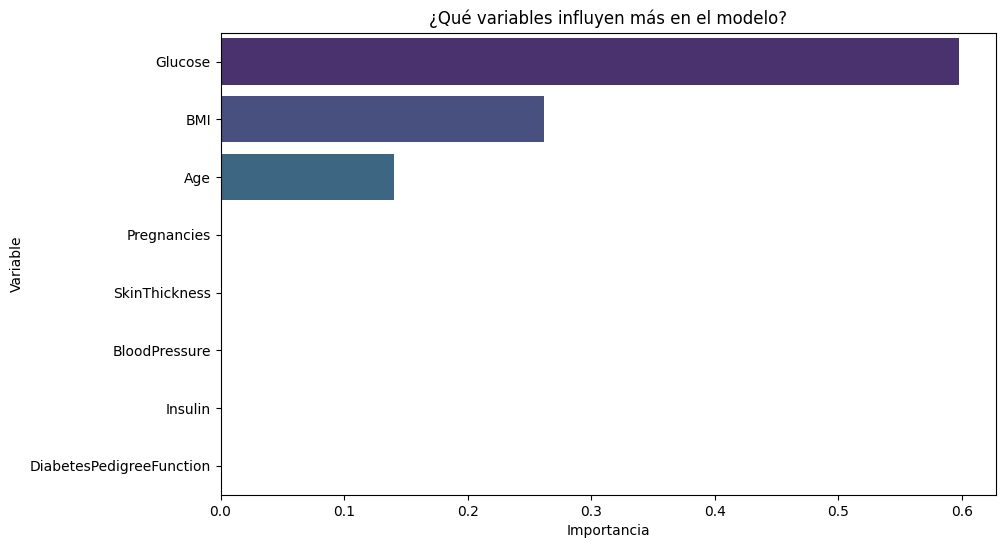

In [21]:
import seaborn as sns

# se extrae la importancia de cada columna
importancia = pd.DataFrame({'Variable': X.columns, 'Importancia': best_model.feature_importances_})
importancia = importancia.sort_values(by='Importancia', ascending=False)

# se crea el gráfico de barras
plt.figure(figsize=(10,6))
sns.barplot(x='Importancia', y='Variable', data=importancia, palette='viridis')
plt.title("¿Qué variables influyen más en el modelo?")
plt.show()

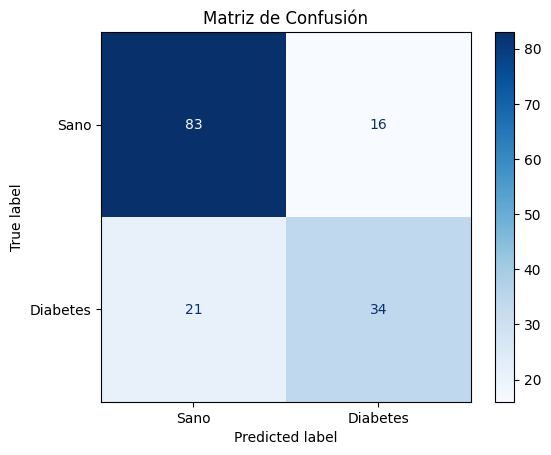

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#  se calcula la matriz
cm = confusion_matrix(y_test, best_model.predict(X_test))

# mostrar la matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Sano", "Diabetes"])
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión")
plt.show()

In [23]:
from pickle import dump

# se guarda el modelo optimizado en la carpeta 'models' 
with open("diabetes_model_final.sav", "wb") as f:
    dump(best_model, f)

print("¡Modelo guardado con éxito como 'diabetes_model_final.sav'!")

¡Modelo guardado con éxito como 'diabetes_model_final.sav'!
